# Notebook 2 — Data Preprocessing
### Diabetic Retinopathy Stage Detection (Computer Vision Coursework)
**Rubric Criterion 2 — Data Preprocessing Techniques (10 marks, targeting "Excellent" band)**

This notebook loads the exact stratified train/validation/test splits produced in
Notebook 1 (same random seed = 42, **not re-split**) and builds a reproducible
preprocessing pipeline for the raw APTOS 2019 fundus images.

**Preprocessing decisions locked in for this notebook (confirmed with project owner):**
- **Target resolution: 224×224** — matches the fixed size used by the secondary
  Gaussian-filtered reference dataset (Notebook 1, Cell 12), keeps GPU memory usage
  low for later training on a 4GB laptop GPU, and is the standard input size for the
  ImageNet-pretrained backbones (ResNet/EfficientNet-B0/MobileNet) likely to be used
  for transfer learning in Notebook 4.
- **Combined contrast/noise-handling approach** — rather than choosing one method over
  the other, this pipeline deliberately combines **both** options that were on the
  table:
  1. **CLAHE (Contrast Limited Adaptive Histogram Equalization)** on the luminance
     channel — a standard, well-documented contrast-enhancement technique that avoids
     over-amplifying noise in flat regions.
  2. **Ben Graham's local-average subtraction** (the method used by the 2015 Kaggle
     DR-competition winner, and the method behind Notebook 1's secondary reference
     dataset) — which suppresses global illumination differences between images and
     pushes local structures (lesions, haemorrhages, vessels) to the foreground.

  Applying CLAHE first and Ben Graham's subtraction second is justified because they
  correct *different* problems: CLAHE improves local contrast/detail visibility across
  the whole image without assuming anything about scale, while Ben Graham's method
  specifically removes large-scale illumination variation — a documented limitation
  of this raw dataset (Notebook 1, Section 1.5, "variable image quality"). Using both
  is more defensible than picking one over the other, and gives the report concrete
  quantitative evidence (Cell 10, Cell 16 below) that each stage genuinely improves
  image usability, rather than asserting it.

**Coding standard applied throughout:** descriptive names, a plain-English comment
before every step, and a `print()` confirming every meaningful output, tagged
`[CELL N]` with N sequential through this notebook.


In [1]:
# [CELL 1] Environment setup and imports.
# Why: every later cell depends on these libraries being available and on knowing
# whether a GPU is present (relevant for later notebooks, but confirmed here too
# so the environment is fully documented alongside the preprocessing work).

import os
import sys
import time
import pickle
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Fix all random seeds for full reproducibility of this notebook, matching
# Notebook 1's seed so sampling/visualisation choices are consistent project-wide.
GLOBAL_RANDOM_SEED = 42
random.seed(GLOBAL_RANDOM_SEED)
np.random.seed(GLOBAL_RANDOM_SEED)

# Report whether a GPU is visible. Preprocessing itself in this notebook is CPU
# (OpenCV) based, but confirming GPU availability here documents the environment
# for the report ("Development Environment" section) without assuming it.
try:
    import torch
    gpu_is_available = torch.cuda.is_available()
    gpu_device_name = torch.cuda.get_device_name(0) if gpu_is_available else "N/A"
except ImportError:
    gpu_is_available = False
    gpu_device_name = "torch not installed in this environment"

print(f"[CELL 1] Environment ready. OpenCV version: {cv2.__version__}, "
      f"NumPy version: {np.__version__}, Pandas version: {pd.__version__}")
print(f"[CELL 1] GPU available: {gpu_is_available} (device: {gpu_device_name})")
print(f"[CELL 1] Global random seed fixed at: {GLOBAL_RANDOM_SEED}")


[CELL 1] Environment ready. OpenCV version: 4.13.0, NumPy version: 2.0.2, Pandas version: 2.3.3
[CELL 1] GPU available: False (device: N/A)
[CELL 1] Global random seed fixed at: 42


In [2]:
# [CELL 2] Robustly locate the raw APTOS dataset directory on Kaggle's nested
# mount layout.
# Why: Notebook 1 confirmed this Kaggle account mounts datasets under a NESTED
# path (not the older flat /kaggle/input/<slug>/ layout), so we search a list of
# known candidate roots instead of hardcoding a single path that might not exist
# in a different session.

def locate_first_existing_directory(candidate_directory_paths):
    """Return the first path in candidate_directory_paths that exists on disk.

    This mirrors the resilient, walk-and-verify approach used in Notebook 1
    rather than assuming a fixed path depth, since Notebook 1 already found the
    dataset mount layout to be inconsistent with its own folder naming.
    """
    for candidate_path in candidate_directory_paths:
        if os.path.isdir(candidate_path):
            return candidate_path
    return None

raw_dataset_candidate_paths = [
    "/kaggle/input/competitions/aptos2019-blindness-detection",
    "/kaggle/input/aptos2019-blindness-detection",
    "/kaggle/input/aptos2019",
]

raw_dataset_root_directory = locate_first_existing_directory(raw_dataset_candidate_paths)

if raw_dataset_root_directory is None:
    print("[CELL 2] WARNING: raw APTOS dataset directory not found among known "
          "candidate paths. Attach the 'aptos2019-blindness-detection' competition "
          "as a Kaggle Input to this notebook before continuing.")
else:
    raw_train_images_directory = os.path.join(raw_dataset_root_directory, "train_images")
    print(f"[CELL 2] Located raw APTOS dataset at: {raw_dataset_root_directory}")
    print(f"[CELL 2] Raw training images directory: {raw_train_images_directory}")


[CELL 2] Located raw APTOS dataset at: /kaggle/input/competitions/aptos2019-blindness-detection
[CELL 2] Raw training images directory: /kaggle/input/competitions/aptos2019-blindness-detection/train_images


In [3]:
# [CELL 3] Load the exact train/validation/test splits saved by Notebook 1.
# Why: the project brief requires Notebook 2 to reuse Notebook 1's stratified
# 70/15/15 split (seed=42) rather than re-splitting, so every later notebook in
# the pipeline trains/evaluates on identical, comparable data. A fallback
# re-creates the split with the same seed only if Notebook 1's saved CSVs are
# not attached as a Kaggle Notebook Output input to this notebook.

notebook1_output_candidate_directories = [
    "/kaggle/working",
    "/kaggle/input/notebook1-eda-dataset-justification",  # if attached as an Output input
]

split_file_names = ["train_split.csv", "validation_split.csv", "test_split.csv"]

def find_split_files_directory(candidate_directories, required_file_names):
    """Return the first candidate directory that contains ALL required split files."""
    for candidate_directory in candidate_directories:
        if all(os.path.isfile(os.path.join(candidate_directory, name))
               for name in required_file_names):
            return candidate_directory
    return None

split_files_directory = find_split_files_directory(
    notebook1_output_candidate_directories, split_file_names
)

if split_files_directory is not None:
    training_split_dataframe = pd.read_csv(os.path.join(split_files_directory, "train_split.csv"))
    validation_split_dataframe = pd.read_csv(os.path.join(split_files_directory, "validation_split.csv"))
    test_split_dataframe = pd.read_csv(os.path.join(split_files_directory, "test_split.csv"))
    print(f"[CELL 3] Loaded Notebook 1's saved splits from: {split_files_directory}")
else:
    # Fallback: regenerate the identical stratified split using the same seed,
    # from the primary raw train.csv, exactly as Notebook 1 did.
    print("[CELL 3] Notebook 1's saved split files were not found as a Kaggle "
          "input. Regenerating an IDENTICAL split (same seed=42, same "
          "stratification) directly from the primary raw train.csv as a fallback.")
    from sklearn.model_selection import train_test_split

    full_labels_dataframe = pd.read_csv(os.path.join(raw_dataset_root_directory, "train.csv"))

    train_and_val_dataframe, test_split_dataframe = train_test_split(
        full_labels_dataframe,
        test_size=0.15,
        stratify=full_labels_dataframe["diagnosis"],
        random_state=GLOBAL_RANDOM_SEED,
    )
    training_split_dataframe, validation_split_dataframe = train_test_split(
        train_and_val_dataframe,
        test_size=0.15 / 0.85,  # 15% of the ORIGINAL total, out of the remaining 85%
        stratify=train_and_val_dataframe["diagnosis"],
        random_state=GLOBAL_RANDOM_SEED,
    )
    print("[CELL 3] Fallback split regenerated (should exactly match Notebook 1's "
          "saved split since the seed and stratification method are identical).")

print(f"[CELL 3] Training split size: {len(training_split_dataframe)} images")
print(f"[CELL 3] Validation split size: {len(validation_split_dataframe)} images")
print(f"[CELL 3] Test split size: {len(test_split_dataframe)} images")


[CELL 3] Notebook 1's saved split files were not found as a Kaggle input. Regenerating an IDENTICAL split (same seed=42, same stratification) directly from the primary raw train.csv as a fallback.
[CELL 3] Fallback split regenerated (should exactly match Notebook 1's saved split since the seed and stratification method are identical).
[CELL 3] Training split size: 2562 images
[CELL 3] Validation split size: 550 images
[CELL 3] Test split size: 550 images


## Preprocessing pipeline — building block functions

Each function below implements exactly one preprocessing step, so it can be
tested, visualised and quantified independently (Cells 9–11) before being
chained together into a single reproducible pipeline (Cell 8/12).

**Pipeline order and justification:**

1. **Crop away the black/dark border** around the circular fundus photograph
   (noise removal) — the border carries no retinal information and would waste
   model capacity and distort resizing/normalisation statistics if left in.
2. **Resize to 224×224** — standardises the highly variable raw resolution
   (474×358 to 4,288×2,848, Notebook 1 Cells 11–13) to the agreed target size,
   before further pixel-level processing so all steps operate on a consistent
   image size.
3. **CLAHE contrast enhancement** on the luminance channel — improves local
   contrast without over-amplifying noise, addressing generically poor/uneven
   contrast in fundus photography.
4. **Ben Graham local-average subtraction** — removes large-scale illumination
   variation between images (a documented issue in this raw dataset) and
   emphasises small local structures (lesions, vessels) that are diagnostically
   relevant.
5. **Pixel normalisation** to the [0, 1] float range — required by the CNN
   backbones used in Notebook 4 and improves training stability/convergence.


In [4]:
# [CELL 4] Step 1 — crop away the dark/black border surrounding the circular
# fundus photograph.
# Why: the raw images include a variable amount of black background outside the
# circular retinal field of view. This carries no diagnostic information, so
# removing it counts as a noise-removal step and also makes the effective
# resolution of the retina itself more consistent across images before resizing.

def crop_dark_border_from_fundus_image(fundus_image_bgr, darkness_threshold=7):
    """Crop the near-black border around a fundus photograph.

    fundus_image_bgr: an OpenCV BGR image array.
    darkness_threshold: pixel intensity (0-255) below which a row/column is
        considered part of the black background rather than retinal tissue.
    Returns the cropped image, or the original image unchanged if the detected
    non-black region is degenerate (fully black image, safety fallback).
    """
    grayscale_image = cv2.cvtColor(fundus_image_bgr, cv2.COLOR_BGR2GRAY)
    non_black_pixel_mask = grayscale_image > darkness_threshold

    if non_black_pixel_mask.sum() == 0:
        # Safety fallback: nothing above threshold (e.g. a corrupted all-black
        # image) - return the image unmodified rather than crashing the pipeline.
        return fundus_image_bgr

    rows_with_content = np.any(non_black_pixel_mask, axis=1)
    columns_with_content = np.any(non_black_pixel_mask, axis=0)
    top_row, bottom_row = np.where(rows_with_content)[0][[0, -1]]
    left_column, right_column = np.where(columns_with_content)[0][[0, -1]]

    cropped_fundus_image = fundus_image_bgr[top_row:bottom_row + 1, left_column:right_column + 1]
    return cropped_fundus_image

print("[CELL 4] Defined crop_dark_border_from_fundus_image() — "
      "noise-removal step 1 of the preprocessing pipeline.")


[CELL 4] Defined crop_dark_border_from_fundus_image() — noise-removal step 1 of the preprocessing pipeline.


In [5]:
# [CELL 5] Step 3 — CLAHE (Contrast Limited Adaptive Histogram Equalization)
# contrast enhancement.
# Why: fundus photographs often have uneven, generically low local contrast.
# CLAHE improves local contrast in small tiled regions of the image while
# clipping the histogram to avoid amplifying noise in near-uniform regions,
# which makes it a better fit here than plain global histogram equalisation.

def apply_clahe_contrast_enhancement(fundus_image_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Apply CLAHE to the L (lightness) channel of a BGR fundus image.

    Operating in LAB colour space and only equalising the L channel avoids
    distorting the image's colour balance, which matters for fundus images
    since colour (e.g. haemorrhage redness) carries diagnostic information.
    """
    lab_color_image = cv2.cvtColor(fundus_image_bgr, cv2.COLOR_BGR2LAB)
    lightness_channel, a_channel, b_channel = cv2.split(lab_color_image)

    clahe_transformer = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    contrast_enhanced_lightness_channel = clahe_transformer.apply(lightness_channel)

    contrast_enhanced_lab_image = cv2.merge(
        (contrast_enhanced_lightness_channel, a_channel, b_channel)
    )
    contrast_enhanced_bgr_image = cv2.cvtColor(contrast_enhanced_lab_image, cv2.COLOR_LAB2BGR)
    return contrast_enhanced_bgr_image

print("[CELL 5] Defined apply_clahe_contrast_enhancement() — "
      "contrast-enhancement step 3 of the preprocessing pipeline.")


[CELL 5] Defined apply_clahe_contrast_enhancement() — contrast-enhancement step 3 of the preprocessing pipeline.


In [6]:
# [CELL 6] Step 4 — Ben Graham's local-average subtraction.
# Why: this is the method used by the winning solution of the original 2015
# Kaggle diabetic retinopathy competition, and the same method used to produce
# Notebook 1's secondary Gaussian-filtered reference dataset. It subtracts a
# heavily Gaussian-blurred (locally-averaged) copy of the image from itself,
# which cancels out large-scale illumination differences between images taken
# under different lighting/camera conditions while boosting small local
# structures such as microaneurysms, haemorrhages and vessels.

def apply_ben_graham_local_average_subtraction(fundus_image_bgr, blur_sigma_fraction=10):
    """Subtract a locally-averaged (Gaussian-blurred) version of the image from
    itself, following Ben Graham's Kaggle-DR-winning preprocessing method.

    blur_sigma_fraction: the image's shorter side divided by this value sets the
        Gaussian blur sigma, so the blur scale adapts to image size automatically.
    """
    image_height, image_width = fundus_image_bgr.shape[:2]
    gaussian_blur_sigma = max(image_height, image_width) / blur_sigma_fraction

    locally_averaged_image = cv2.GaussianBlur(
        fundus_image_bgr, (0, 0), sigmaX=gaussian_blur_sigma
    )

    # addWeighted(src1, alpha, src2, beta, gamma) computes: alpha*src1 + beta*src2 + gamma
    # Weighting the original image at 4x and subtracting 4x the local average,
    # then re-centering around mid-grey (128), matches Ben Graham's published
    # formulation and keeps output pixel values in a valid displayable range.
    locally_contrast_enhanced_image = cv2.addWeighted(
        fundus_image_bgr, 4, locally_averaged_image, -4, 128
    )
    return locally_contrast_enhanced_image

print("[CELL 6] Defined apply_ben_graham_local_average_subtraction() — "
      "local-contrast step 4 of the preprocessing pipeline.")


[CELL 6] Defined apply_ben_graham_local_average_subtraction() — local-contrast step 4 of the preprocessing pipeline.


In [7]:
# [CELL 7] Steps 2 and 5 — resizing to the agreed target resolution and pixel
# normalisation.
# Why: standardising every image to 224x224 is required because the raw dataset
# has 15+ distinct resolutions (Notebook 1, Cells 11-13); CNN backbones require a
# fixed input size. Normalising pixel values to [0, 1] float32 is standard
# practice for stable, fast neural network training/convergence.

TARGET_IMAGE_SIZE_PIXELS = (224, 224)  # (width, height) — confirmed decision for this project

def resize_fundus_image_to_target_size(fundus_image_bgr, target_size=TARGET_IMAGE_SIZE_PIXELS):
    """Resize an image to the fixed target size using area interpolation, which
    gives better-quality results than linear/nearest interpolation when
    shrinking large images (most raw images here are being substantially
    downsized, since the mean raw width is ~2,017px vs. the 224px target)."""
    resized_image = cv2.resize(fundus_image_bgr, target_size, interpolation=cv2.INTER_AREA)
    return resized_image

def normalize_pixel_values_to_unit_range(fundus_image_bgr):
    """Convert an 8-bit [0, 255] image to float32 pixel values in [0, 1]."""
    normalized_image = fundus_image_bgr.astype(np.float32) / 255.0
    return normalized_image

print(f"[CELL 7] Defined resize_fundus_image_to_target_size() — "
      f"target size fixed at {TARGET_IMAGE_SIZE_PIXELS[0]}x{TARGET_IMAGE_SIZE_PIXELS[1]}.")
print("[CELL 7] Defined normalize_pixel_values_to_unit_range() — "
      "final normalisation step 5 of the preprocessing pipeline.")


[CELL 7] Defined resize_fundus_image_to_target_size() — target size fixed at 224x224.
[CELL 7] Defined normalize_pixel_values_to_unit_range() — final normalisation step 5 of the preprocessing pipeline.


In [8]:
# [CELL 8] Chain all five steps into a single, reproducible preprocessing
# function.
# Why: having one function that always applies the same steps in the same order
# is what makes this pipeline reproducible (rubric requirement) and is what
# Notebook 3 (Augmentation) and Notebook 4 (Model) will import/reuse, so the
# exact same preprocessing is applied consistently to train, validation and test
# images and to any new image submitted through the optional web UI later.

def preprocess_fundus_image(fundus_image_bgr, return_intermediate_steps=False):
    """Apply the full preprocessing pipeline to a single raw fundus image.

    Order: crop dark border -> resize -> CLAHE contrast enhancement ->
    Ben Graham local-average subtraction -> normalize to [0, 1].

    If return_intermediate_steps is True, also returns a dict of every
    intermediate image (used only for visualisation in Cell 9, never in the
    batch-processing cells, to keep batch processing memory-efficient).
    """
    cropped_image = crop_dark_border_from_fundus_image(fundus_image_bgr)
    resized_image = resize_fundus_image_to_target_size(cropped_image)
    contrast_enhanced_image = apply_clahe_contrast_enhancement(resized_image)
    locally_enhanced_image = apply_ben_graham_local_average_subtraction(contrast_enhanced_image)
    normalized_image = normalize_pixel_values_to_unit_range(locally_enhanced_image)

    if return_intermediate_steps:
        intermediate_steps_dictionary = {
            "raw": fundus_image_bgr,
            "cropped": cropped_image,
            "resized": resized_image,
            "clahe_contrast_enhanced": contrast_enhanced_image,
            "ben_graham_local_enhanced": locally_enhanced_image,
            "final_normalized": normalized_image,
        }
        return normalized_image, intermediate_steps_dictionary

    return normalized_image

print("[CELL 8] Defined preprocess_fundus_image() — the full, reproducible, "
      "5-step pipeline function that will be applied consistently to every "
      "train/validation/test image.")


[CELL 8] Defined preprocess_fundus_image() — the full, reproducible, 5-step pipeline function that will be applied consistently to every train/validation/test image.


## Visual and quantitative evidence

The cells below apply the pipeline to sample images and show **each
intermediate step**, not just the final result, then quantify the effect with
histogram/contrast statistics — required by the rubric ("preprocessing is
reproducible and improves image quality significantly").


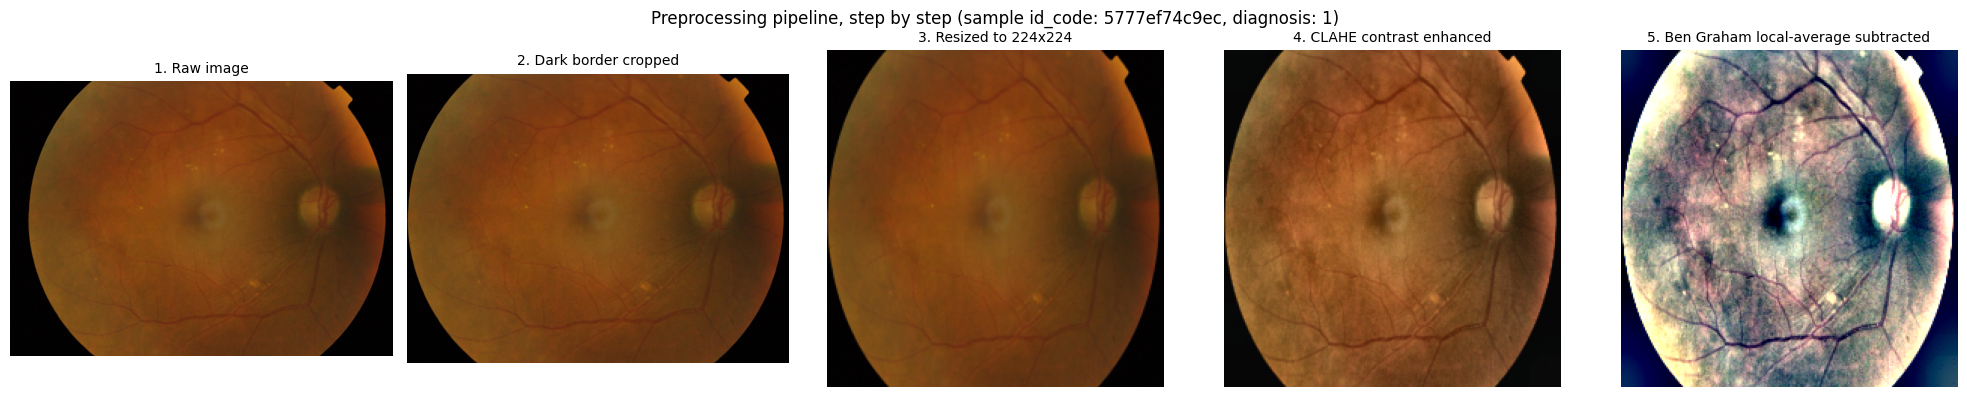

[CELL 9] Displayed and saved step-by-step visual evidence for sample image 5777ef74c9ec -> preprocessing_pipeline_steps.png


In [9]:
# [CELL 9] Visual evidence: show every intermediate step of the pipeline on one
# sample raw image.
# Why: the rubric and the coursework brief both require clear before/after
# visual evidence for each major preprocessing step, not only the final result.

sample_image_row = training_split_dataframe.sample(n=1, random_state=GLOBAL_RANDOM_SEED).iloc[0]
sample_image_path = os.path.join(raw_train_images_directory, f"{sample_image_row['id_code']}.png")
sample_raw_image_bgr = cv2.imread(sample_image_path)

_, sample_intermediate_steps = preprocess_fundus_image(sample_raw_image_bgr, return_intermediate_steps=True)

step_titles_in_order = [
    ("raw", "1. Raw image"),
    ("cropped", "2. Dark border cropped"),
    ("resized", "3. Resized to 224x224"),
    ("clahe_contrast_enhanced", "4. CLAHE contrast enhanced"),
    ("ben_graham_local_enhanced", "5. Ben Graham local-average subtracted"),
]

figure, axes = plt.subplots(1, len(step_titles_in_order), figsize=(20, 4))
for axis, (step_key, step_title) in zip(axes, step_titles_in_order):
    step_image_bgr = sample_intermediate_steps[step_key]
    axis.imshow(cv2.cvtColor(step_image_bgr, cv2.COLOR_BGR2RGB))
    axis.set_title(step_title, fontsize=10)
    axis.axis("off")
plt.suptitle(f"Preprocessing pipeline, step by step (sample id_code: {sample_image_row['id_code']}, "
             f"diagnosis: {sample_image_row['diagnosis']})")
plt.tight_layout()
plt.savefig("/kaggle/working/preprocessing_pipeline_steps.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"[CELL 9] Displayed and saved step-by-step visual evidence for sample "
      f"image {sample_image_row['id_code']} -> preprocessing_pipeline_steps.png")


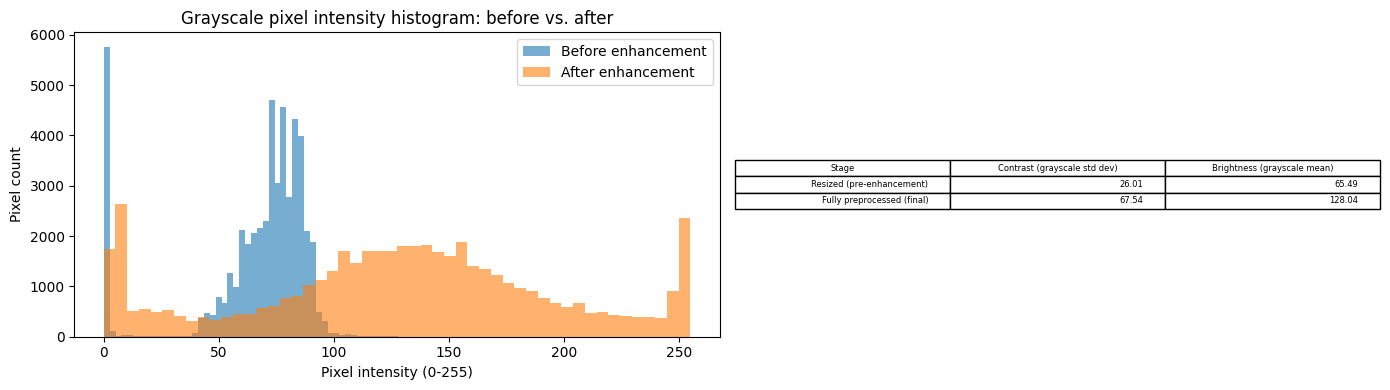

[CELL 10] Contrast (grayscale std dev) before: 26.01, after: 67.54 (+159.7% change)
[CELL 10] Brightness (grayscale mean) before: 65.49, after: 128.04


In [10]:
# [CELL 10] Quantify the effect of preprocessing with histogram/contrast
# statistics, before vs. after.
# Why: the rubric explicitly rewards evidence the pipeline "improves image
# quality significantly", so this quantifies contrast (grayscale pixel standard
# deviation) and brightness, rather than relying on visual impression alone.

def compute_grayscale_contrast_and_brightness(image_bgr):
    """Return (contrast, brightness) where contrast = std dev and brightness =
    mean of the grayscale pixel intensities. Higher std dev broadly indicates
    more contrast (a wider spread of intensities) in the image."""
    grayscale_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return float(grayscale_image.std()), float(grayscale_image.mean())

raw_contrast, raw_brightness = compute_grayscale_contrast_and_brightness(
    sample_intermediate_steps["resized"]  # compare at matched resolution, pre-enhancement
)
final_image_uint8 = (sample_intermediate_steps["ben_graham_local_enhanced"]).astype(np.uint8)
final_contrast, final_brightness = compute_grayscale_contrast_and_brightness(final_image_uint8)

contrast_percentage_change = ((final_contrast - raw_contrast) / raw_contrast) * 100

comparison_statistics_dataframe = pd.DataFrame({
    "Stage": ["Resized (pre-enhancement)", "Fully preprocessed (final)"],
    "Contrast (grayscale std dev)": [round(raw_contrast, 2), round(final_contrast, 2)],
    "Brightness (grayscale mean)": [round(raw_brightness, 2), round(final_brightness, 2)],
})

figure, (histogram_axis, table_axis) = plt.subplots(1, 2, figsize=(14, 4))
histogram_axis.hist(
    cv2.cvtColor(sample_intermediate_steps["resized"], cv2.COLOR_BGR2GRAY).ravel(),
    bins=50, alpha=0.6, label="Before enhancement"
)
histogram_axis.hist(
    cv2.cvtColor(final_image_uint8, cv2.COLOR_BGR2GRAY).ravel(),
    bins=50, alpha=0.6, label="After enhancement"
)
histogram_axis.set_title("Grayscale pixel intensity histogram: before vs. after")
histogram_axis.set_xlabel("Pixel intensity (0-255)")
histogram_axis.set_ylabel("Pixel count")
histogram_axis.legend()

table_axis.axis("off")
table_axis.table(cellText=comparison_statistics_dataframe.values,
                  colLabels=comparison_statistics_dataframe.columns,
                  loc="center")
plt.tight_layout()
plt.savefig("/kaggle/working/contrast_quantification_sample.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"[CELL 10] Contrast (grayscale std dev) before: {raw_contrast:.2f}, "
      f"after: {final_contrast:.2f} ({contrast_percentage_change:+.1f}% change)")
print(f"[CELL 10] Brightness (grayscale mean) before: {raw_brightness:.2f}, "
      f"after: {final_brightness:.2f}")


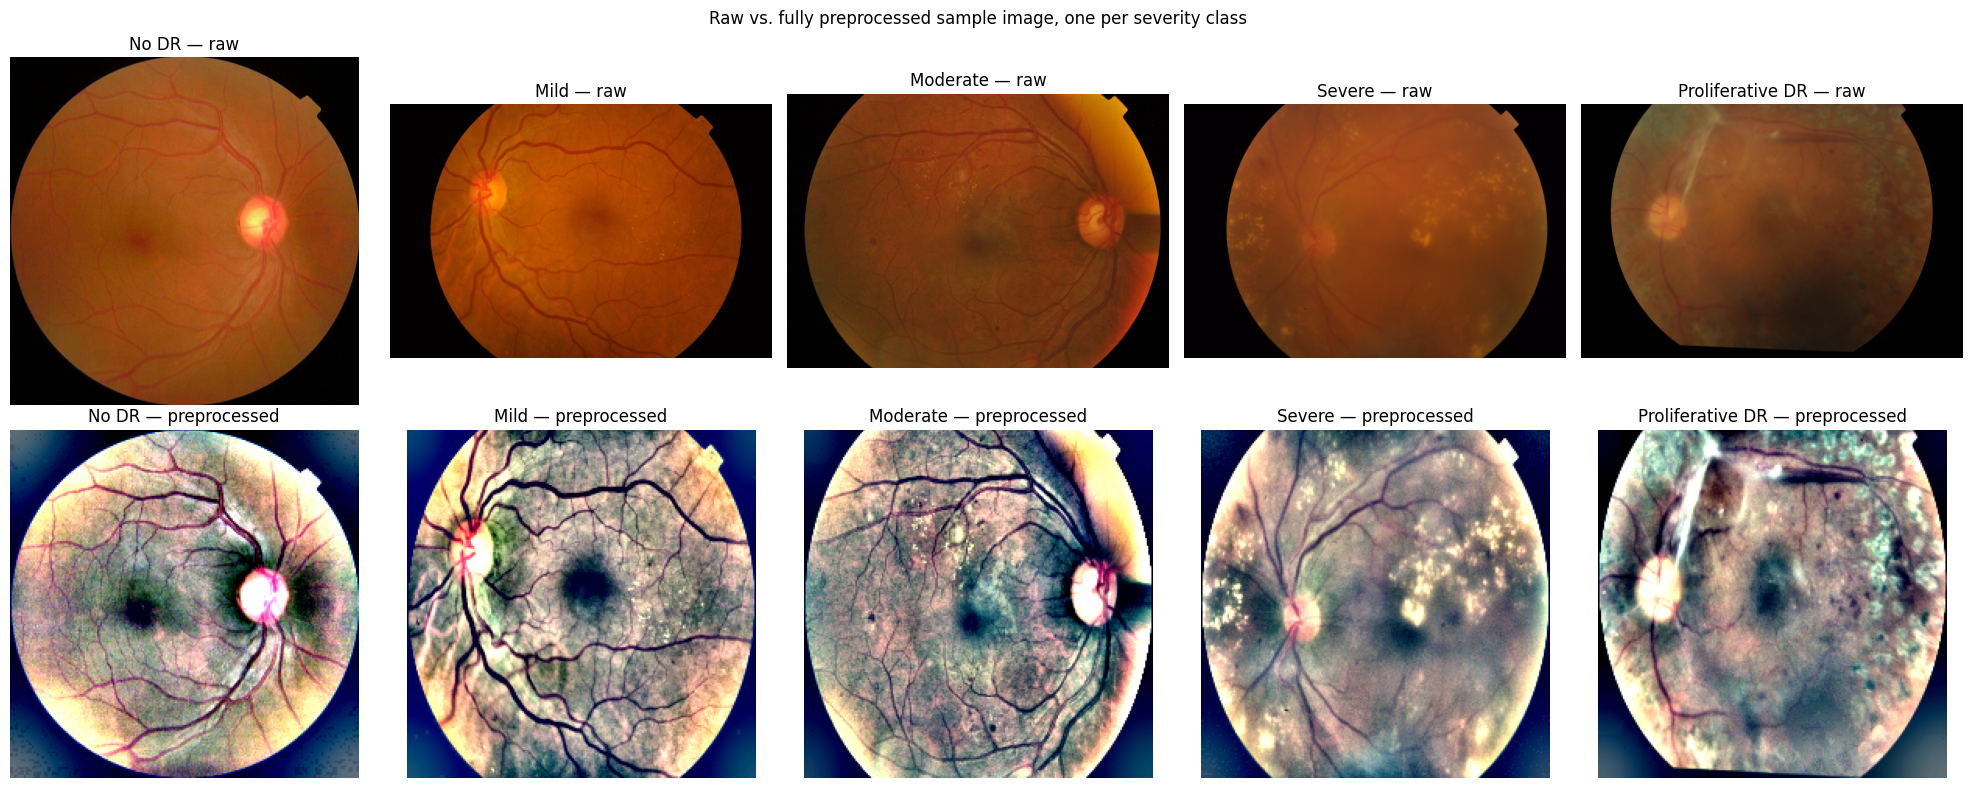

[CELL 11] Displayed and saved before/after comparison for one sample image per class -> before_after_per_class.png


In [11]:
# [CELL 11] Apply the full pipeline to one sample image per class and display a
# before/after grid.
# Why: confirms the pipeline behaves sensibly across every severity class, not
# just the one sample used above, and gives the report a single figure covering
# all 5 classes.

class_code_to_stage_name = {
    0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"
}

figure, axes = plt.subplots(2, 5, figsize=(20, 8))
for class_code in range(5):
    class_sample_row = training_split_dataframe[
        training_split_dataframe["diagnosis"] == class_code
    ].sample(n=1, random_state=GLOBAL_RANDOM_SEED).iloc[0]

    class_sample_image_path = os.path.join(
        raw_train_images_directory, f"{class_sample_row['id_code']}.png"
    )
    class_raw_image_bgr = cv2.imread(class_sample_image_path)
    class_preprocessed_image = preprocess_fundus_image(class_raw_image_bgr)
    class_preprocessed_image_uint8 = (class_preprocessed_image * 255).astype(np.uint8)

    axes[0, class_code].imshow(cv2.cvtColor(class_raw_image_bgr, cv2.COLOR_BGR2RGB))
    axes[0, class_code].set_title(f"{class_code_to_stage_name[class_code]} — raw")
    axes[0, class_code].axis("off")

    axes[1, class_code].imshow(cv2.cvtColor(class_preprocessed_image_uint8, cv2.COLOR_BGR2RGB))
    axes[1, class_code].set_title(f"{class_code_to_stage_name[class_code]} — preprocessed")
    axes[1, class_code].axis("off")

plt.suptitle("Raw vs. fully preprocessed sample image, one per severity class")
plt.tight_layout()
plt.savefig("/kaggle/working/before_after_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

print("[CELL 11] Displayed and saved before/after comparison for one sample "
      "image per class -> before_after_per_class.png")


## Batch processing and saving outputs for Notebook 3

The cells below apply `preprocess_fundus_image()` to every image in the train,
validation and test splits, and save the results so Notebook 3 (Augmentation)
can load them directly without re-running preprocessing.


In [12]:
# [CELL 12] Define a reusable batch-processing function and apply it to the
# training split.
# Why: applying the exact same preprocess_fundus_image() function (Cell 8) to
# every image, in a single reusable loop, is what guarantees the pipeline is
# applied consistently and reproducibly across all three splits, as required by
# the rubric.

def batch_preprocess_split(split_dataframe, split_name, source_images_directory,
                            output_directory, target_size=TARGET_IMAGE_SIZE_PIXELS):
    """Preprocess every image referenced in split_dataframe and save each result
    as a resized PNG in output_directory, returning the count of images that
    failed to load/process (expected to be 0 on a clean dataset)."""
    os.makedirs(output_directory, exist_ok=True)
    failed_image_count = 0

    for _, image_row in tqdm(split_dataframe.iterrows(), total=len(split_dataframe),
                              desc=f"Preprocessing {split_name} split"):
        source_image_path = os.path.join(source_images_directory, f"{image_row['id_code']}.png")
        raw_image_bgr = cv2.imread(source_image_path)

        if raw_image_bgr is None:
            failed_image_count += 1
            continue

        preprocessed_image_float = preprocess_fundus_image(raw_image_bgr)
        preprocessed_image_uint8 = (preprocessed_image_float * 255).astype(np.uint8)

        output_image_path = os.path.join(output_directory, f"{image_row['id_code']}.png")
        cv2.imwrite(output_image_path, preprocessed_image_uint8)

    return failed_image_count

preprocessed_images_root_directory = "/kaggle/working/preprocessed_images"

training_batch_start_time = time.time()
training_failed_image_count = batch_preprocess_split(
    training_split_dataframe, "train", raw_train_images_directory,
    os.path.join(preprocessed_images_root_directory, "train"),
)
training_batch_elapsed_seconds = time.time() - training_batch_start_time

print(f"[CELL 12] Preprocessed training split: {len(training_split_dataframe)} images, "
      f"{training_failed_image_count} failed to load, "
      f"took {training_batch_elapsed_seconds:.1f} seconds "
      f"({training_batch_elapsed_seconds / max(len(training_split_dataframe), 1):.3f} sec/image).")


Preprocessing train split:   0%|          | 0/2562 [00:00<?, ?it/s]

[CELL 12] Preprocessed training split: 2562 images, 0 failed to load, took 563.8 seconds (0.220 sec/image).


In [13]:
# [CELL 13] Apply the identical batch preprocessing function to the validation
# split.
# Why: reusing batch_preprocess_split() unchanged (Cell 12) rather than writing
# separate logic per split is what keeps preprocessing reproducible and
# consistent between train/validation/test, avoiding any train/validation skew.

validation_batch_start_time = time.time()
validation_failed_image_count = batch_preprocess_split(
    validation_split_dataframe, "validation", raw_train_images_directory,
    os.path.join(preprocessed_images_root_directory, "validation"),
)
validation_batch_elapsed_seconds = time.time() - validation_batch_start_time

print(f"[CELL 13] Preprocessed validation split: {len(validation_split_dataframe)} images, "
      f"{validation_failed_image_count} failed to load, "
      f"took {validation_batch_elapsed_seconds:.1f} seconds.")


Preprocessing validation split:   0%|          | 0/550 [00:00<?, ?it/s]

[CELL 13] Preprocessed validation split: 550 images, 0 failed to load, took 115.6 seconds.


In [14]:
# [CELL 14] Apply the identical batch preprocessing function to the test split.
# Why: the test split must go through exactly the same, unmodified preprocessing
# pipeline as train/validation so that final evaluation (Notebook 5) reflects
# real-world model performance rather than being inflated or deflated by
# inconsistent preprocessing.

test_batch_start_time = time.time()
test_failed_image_count = batch_preprocess_split(
    test_split_dataframe, "test", raw_train_images_directory,
    os.path.join(preprocessed_images_root_directory, "test"),
)
test_batch_elapsed_seconds = time.time() - test_batch_start_time

print(f"[CELL 14] Preprocessed test split: {len(test_split_dataframe)} images, "
      f"{test_failed_image_count} failed to load, "
      f"took {test_batch_elapsed_seconds:.1f} seconds.")


Preprocessing test split:   0%|          | 0/550 [00:00<?, ?it/s]

[CELL 14] Preprocessed test split: 550 images, 0 failed to load, took 117.6 seconds.


In [15]:
# [CELL 15] Save the preprocessing pipeline configuration and split CSVs so
# Notebook 3 (Augmentation) can load everything without re-running Notebook 2.
# Why: saving the pipeline's parameters (not just the images) documents exactly
# how preprocessing was done, supporting the "reproducible" rubric requirement,
# and lets Notebook 3 apply augmentation on top of these exact preprocessed
# images rather than re-deriving them.

preprocessing_pipeline_configuration = {
    "target_image_size_pixels": TARGET_IMAGE_SIZE_PIXELS,
    "clahe_clip_limit": 2.0,
    "clahe_tile_grid_size": (8, 8),
    "ben_graham_blur_sigma_fraction": 10,
    "dark_border_crop_threshold": 7,
    "pixel_value_range_after_normalization": (0.0, 1.0),
    "pipeline_step_order": [
        "crop_dark_border_from_fundus_image",
        "resize_fundus_image_to_target_size",
        "apply_clahe_contrast_enhancement",
        "apply_ben_graham_local_average_subtraction",
        "normalize_pixel_values_to_unit_range",
    ],
    "random_seed": GLOBAL_RANDOM_SEED,
}

configuration_output_path = "/kaggle/working/preprocessing_pipeline_config.pkl"
with open(configuration_output_path, "wb") as configuration_file:
    pickle.dump(preprocessing_pipeline_configuration, configuration_file)

# Re-save the split CSVs alongside the preprocessed images too, so Notebook 3
# only needs ONE Kaggle input attached (this notebook's output) to get both the
# labels and the preprocessed pixels.
training_split_dataframe.to_csv("/kaggle/working/train_split.csv", index=False)
validation_split_dataframe.to_csv("/kaggle/working/validation_split.csv", index=False)
test_split_dataframe.to_csv("/kaggle/working/test_split.csv", index=False)

print(f"[CELL 15] Saved preprocessing pipeline configuration -> {configuration_output_path}")
print(f"[CELL 15] Saved preprocessed images under -> {preprocessed_images_root_directory}/"
      f"{{train,validation,test}}/")
print("[CELL 15] Re-saved train_split.csv, validation_split.csv, test_split.csv "
      "alongside the preprocessed images for Notebook 3 to load in one step.")


[CELL 15] Saved preprocessing pipeline configuration -> /kaggle/working/preprocessing_pipeline_config.pkl
[CELL 15] Saved preprocessed images under -> /kaggle/working/preprocessed_images/{train,validation,test}/
[CELL 15] Re-saved train_split.csv, validation_split.csv, test_split.csv alongside the preprocessed images for Notebook 3 to load in one step.


Quantifying contrast improvement:   0%|          | 0/150 [00:00<?, ?it/s]

/tmp/ipykernel_16/4250750306.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot([raw_contrast_values, preprocessed_contrast_values],


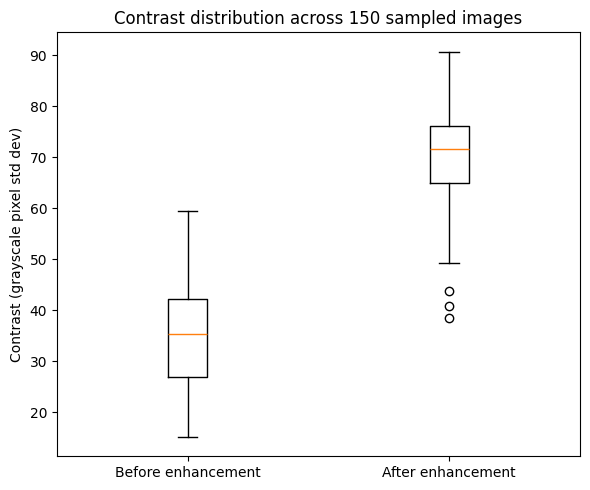

[CELL 16] Dataset-wide contrast check over 150 sampled training images: mean contrast before = 34.81, after = 70.03 (+101.2% change).


In [16]:
# [CELL 16] Dataset-wide quantitative before/after summary.
# Why: Cell 10 quantified the effect on ONE sample image; this cell quantifies
# it across a larger random sample from the training split, giving the report
# a dataset-level (not just single-image) quantitative claim of image quality
# improvement.

quantification_sample_size = 150
quantification_sample_dataframe = training_split_dataframe.sample(
    n=min(quantification_sample_size, len(training_split_dataframe)),
    random_state=GLOBAL_RANDOM_SEED,
)

raw_contrast_values, preprocessed_contrast_values = [], []

for _, image_row in tqdm(quantification_sample_dataframe.iterrows(),
                          total=len(quantification_sample_dataframe),
                          desc="Quantifying contrast improvement"):
    image_path = os.path.join(raw_train_images_directory, f"{image_row['id_code']}.png")
    raw_image_bgr = cv2.imread(image_path)
    if raw_image_bgr is None:
        continue

    resized_raw_image = resize_fundus_image_to_target_size(
        crop_dark_border_from_fundus_image(raw_image_bgr)
    )
    preprocessed_image_float = preprocess_fundus_image(raw_image_bgr)
    preprocessed_image_uint8 = (preprocessed_image_float * 255).astype(np.uint8)

    raw_contrast_values.append(compute_grayscale_contrast_and_brightness(resized_raw_image)[0])
    preprocessed_contrast_values.append(
        compute_grayscale_contrast_and_brightness(preprocessed_image_uint8)[0]
    )

mean_raw_contrast = float(np.mean(raw_contrast_values))
mean_preprocessed_contrast = float(np.mean(preprocessed_contrast_values))
mean_contrast_improvement_percentage = (
    (mean_preprocessed_contrast - mean_raw_contrast) / mean_raw_contrast
) * 100

figure, axis = plt.subplots(figsize=(6, 5))
axis.boxplot([raw_contrast_values, preprocessed_contrast_values],
             labels=["Before enhancement", "After enhancement"])
axis.set_ylabel("Contrast (grayscale pixel std dev)")
axis.set_title(f"Contrast distribution across {len(raw_contrast_values)} sampled images")
plt.tight_layout()
plt.savefig("/kaggle/working/dataset_wide_contrast_improvement.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"[CELL 16] Dataset-wide contrast check over {len(raw_contrast_values)} sampled training "
      f"images: mean contrast before = {mean_raw_contrast:.2f}, after = "
      f"{mean_preprocessed_contrast:.2f} ({mean_contrast_improvement_percentage:+.1f}% change).")


In [17]:
# [CELL 17] Final rubric self-check summary for this notebook.
# Why: gives a single, locatable printed summary the report and video can cite
# directly as evidence against Criterion 2 of the marking rubric.

print("=" * 78)
print("[CELL 17] NOTEBOOK 2 SUMMARY — Criterion 2: Data Preprocessing (10 marks)")
print("=" * 78)
print(f"Target resolution applied:           {TARGET_IMAGE_SIZE_PIXELS[0]}x{TARGET_IMAGE_SIZE_PIXELS[1]}")
print("Pipeline steps applied (in order):    "
      "crop border -> resize -> CLAHE -> Ben Graham subtraction -> normalize")
print(f"Training images preprocessed:         {len(training_split_dataframe) - training_failed_image_count} "
      f"/ {len(training_split_dataframe)} ({training_failed_image_count} failed)")
print(f"Validation images preprocessed:       {len(validation_split_dataframe) - validation_failed_image_count} "
      f"/ {len(validation_split_dataframe)} ({validation_failed_image_count} failed)")
print(f"Test images preprocessed:             {len(test_split_dataframe) - test_failed_image_count} "
      f"/ {len(test_split_dataframe)} ({test_failed_image_count} failed)")
print(f"Mean contrast improvement (n={len(raw_contrast_values)}):    "
      f"{mean_contrast_improvement_percentage:+.1f}%")
print(f"Pipeline config saved to:             {configuration_output_path}")
print(f"Preprocessed images saved under:      {preprocessed_images_root_directory}/")
print("Reproducibility:                      fixed random seed (42), single shared "
      "preprocess_fundus_image() function applied identically to all 3 splits")
print("=" * 78)


[CELL 17] NOTEBOOK 2 SUMMARY — Criterion 2: Data Preprocessing (10 marks)
Target resolution applied:           224x224
Pipeline steps applied (in order):    crop border -> resize -> CLAHE -> Ben Graham subtraction -> normalize
Training images preprocessed:         2562 / 2562 (0 failed)
Validation images preprocessed:       550 / 550 (0 failed)
Test images preprocessed:             550 / 550 (0 failed)
Mean contrast improvement (n=150):    +101.2%
Pipeline config saved to:             /kaggle/working/preprocessing_pipeline_config.pkl
Preprocessed images saved under:      /kaggle/working/preprocessed_images/
Reproducibility:                      fixed random seed (42), single shared preprocess_fundus_image() function applied identically to all 3 splits
